In [98]:
import os
import re
import csv
import numpy as np
import pandas as pd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/6_ICOHP'
# oxygen_potential = -4.658724749999999 # 300K
# oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
oxygen_potential = -4.658724749999999+0.27-0.85 # 800K
figsize = (4, 3)
dpi = 300

In [99]:
# import shutil
# import glob

# folder_to_remove = os.path.join(root, "4_slab_M-RuO2", "3_cus_O_O", "1_Hf")
# files = glob.glob(os.path.join(folder_to_remove, '*'))
# for f in files:
#     try:
#         if os.path.isfile(f) or os.path.islink(f):
#             os.remove(f)
#         elif os.path.isdir(f):
#             shutil.rmtree(f)
#     except Exception as e:
#         print(f"Failed to delete {f}. Reason: {e}")

In [100]:
data = pd.DataFrame(index=['Ru', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt'])
subdirs = ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os', '6_Ir', '7_Pt']

In [101]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy', '3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        energy_file = os.path.join(path, 'final_with_calculator.json')
        if os.path.exists(energy_file):
            atoms = read(energy_file)
            n_atoms = len(atoms)
            n_oxygens = sum(atom.symbol == 'O' for atom in atoms)
            n_metals = n_atoms - n_oxygens
            oxidation_state = 2 * n_oxygens / n_metals
            energy = atoms.get_potential_energy() / n_metals
            data.loc[element, f'{oxide_type}_energy'] = energy
            if oxide_type == 'MxOy':
                data.loc[element, f'{oxide_type}_os'] = oxidation_state

data['MO2_fe'] = (data['MO2_energy'] - (data['MxOy_energy'] + oxygen_potential * (2 - data['MxOy_os'] / 2)))/3
data['M-RuO2_fe'] = (data['M-RuO2_energy'] - 1/8*data['MxOy_energy'] - 7/8*(data['MxOy_energy']['Ru'] - 1/16*oxygen_potential*(4-data['MxOy_os']['Ru'])))/3
data['MxOy_fe'] = data['MxOy_energy']*0
# data.drop(columns=['MO2_energy', 'MxOy_energy', 'M-RuO2_energy'], inplace=True)
data


,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00


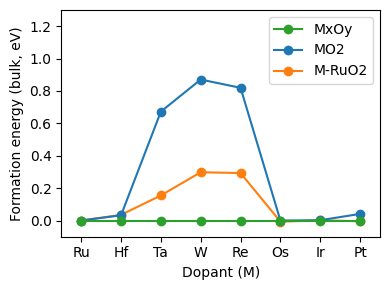

In [102]:
plt.figure(figsize=figsize)

cols = ['MxOy_fe', 'MO2_fe', 'M-RuO2_fe']
labels = ['MxOy', 'MO2', 'M-RuO2']
colors = ['tab:green', 'tab:blue', 'tab:orange']
zorders = [3, 2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('Formation energy (bulk, eV)')
plt.ylim(-0.1, 1.3)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_formation_energy.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

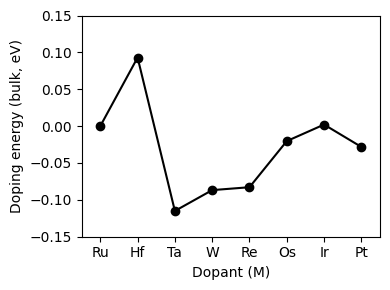

In [103]:
data['bulk_de'] = data['M-RuO2_energy'] - 1/8 * data['MO2_energy'] - 7/8 * data['MO2_energy']['Ru']

plt.figure(figsize=figsize)

plt.plot(
    data.index, 
    data['bulk_de'], 
    marker='o', 
    color='black', 
)

plt.xlabel('Dopant (M)')
plt.ylabel('Doping energy (bulk, eV)')
plt.ylim(-0.15, 0.15)

plt.xlim(-0.5, 7.5)
# plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_doping_energy_bulk.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [104]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        chg_file = os.path.join(path, 'atoms_bader_charge.json')
        if os.path.exists(chg_file):
            atoms = read(chg_file)
            chgs = atoms.get_initial_charges()
            metal_chgs = [chg for atom, chg in zip(atoms, chgs) if atom.symbol != 'O']
            chg_metal = sum(metal_chgs) / len(metal_chgs)
            data.loc[element, f'{oxide_type}_chg'] = chg_metal
        mag_file = os.path.join(path, 'moments.json')
        if os.path.exists(mag_file):
            atoms = read(mag_file)
            mags = atoms.get_magnetic_moments()
            metal_mags = [abs(mag) for atom, mag in zip(atoms, mags) if atom.symbol != 'O']
            mag_metal = sum(metal_mags) / len(metal_mags)
            data.loc[element, f'{oxide_type}_mag'] = mag_metal
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00


In [105]:
for dir in ['3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        atoms = read(os.path.join(path, 'final_with_calculator.json'))
        if element == 'Ru':
            M_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
            Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
        else:
            M_index = [i for i, atom in enumerate(atoms) if atom.symbol != 'O' and atom.symbol != 'Ru']
            Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru' and i != 4]
        
        chg_file = os.path.join(path, 'atoms_bader_charge.json')
        if os.path.exists(chg_file):
            atoms = read(chg_file)
            chgs = atoms.get_initial_charges()
            M_chg = sum(chgs[M_index])/len(M_index)
            Ru_chg = sum(chgs[Ru_index])/len(Ru_index)
            data.loc[element, f'{oxide_type}_chg_M'] = M_chg
            data.loc[element, f'{oxide_type}_chg_Ru'] = Ru_chg

        mag_file = os.path.join(path, 'moments.json')
        if os.path.exists(mag_file):
            atoms = read(mag_file)
            mags = atoms.get_magnetic_moments()
            M_mag = sum(abs(mags[i]) for i in M_index) / len(M_index)
            Ru_mag = sum(abs(mags[i]) for i in Ru_index) / len(Ru_index)
            data.loc[element, f'{oxide_type}_mag_M'] = M_mag
            data.loc[element, f'{oxide_type}_mag_Ru'] = Ru_mag
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31


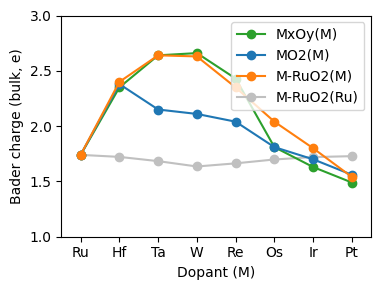

In [106]:
plt.figure(figsize=figsize)

cols = ['MxOy_chg', 'MO2_chg', 'M-RuO2_chg_M', 'M-RuO2_chg_Ru']
labels = ['MxOy(M)', 'MO2(M)', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [2, 3, 4, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

# plt.title('MO2 vs M-RuO2')
plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (bulk, e)')
plt.ylim(1.0, 3.0)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

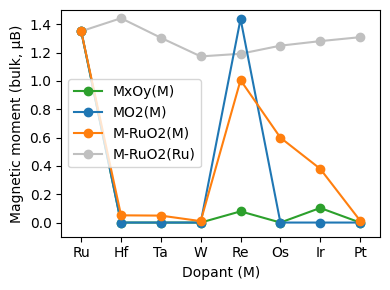

In [107]:
plt.figure(figsize=figsize)

cols = ['MxOy_mag', 'MO2_mag', 'M-RuO2_mag_M', 'M-RuO2_mag_Ru']
labels = ['MxOy(M)', 'MO2(M)', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [2, 3, 4, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

# plt.title('MO2 vs M-RuO2')
plt.xlabel('Dopant (M)')
plt.ylabel('Magnetic moment (bulk, μB)')
plt.ylim(-0.1, 1.5)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [108]:
def calculate_icohp_means_MO2(icohp_file):
    """
    Read one icohplist.txt file, extract the 7th column,
    and compute overall means across all complete chunks of 6 values.

    Chunk split rule:
    - First 4 chunks: split as 2 / 4
    - Remaining chunks: split as 4 / 2

    Then compute:
    - overall mean of all values from the 2-value groups
    - overall mean of all values from the 4-value groups
    """
    col7_values = []
    with open(icohp_file, 'r') as file:
        for line in file:
            columns = line.strip().split()
            if len(columns) >= 8:
                col7_values.append(columns[6])

    # Drop the first entry because it is the column header ('-ICOHP').
    numeric_values = [float(x) for x in col7_values[1:]]

    all_two_group = []
    all_four_group = []

    chunk_idx = 0
    for i in range(0, len(numeric_values), 6):
        chunk = numeric_values[i:i+6]
        if len(chunk) != 6:
            continue

        if chunk_idx < 4:
            all_two_group.extend(chunk[:2])
            all_four_group.extend(chunk[2:])
        else:
            all_four_group.extend(chunk[:4])
            all_two_group.extend(chunk[4:])

        chunk_idx += 1

    if not all_two_group or not all_four_group:
        return None

    overall_mean_axial = sum(all_two_group) / len(all_two_group)
    overall_mean_equatorial = sum(all_four_group) / len(all_four_group)
    overall_mean = sum(all_two_group + all_four_group) / len(all_two_group + all_four_group)

    return overall_mean_axial, overall_mean_equatorial, overall_mean

for dir in ['1_bulk_MO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        icohp_file = os.path.join(root, dir, 'cohp', subdir, 'icohplist.txt')
        if os.path.exists(icohp_file):
            means = calculate_icohp_means_MO2(icohp_file)
            if means is not None:
                mean_axial, mean_equatorial, mean_overall = means
                data.loc[element, f'{oxide_type}_icohp_z'] = mean_axial
                data.loc[element, f'{oxide_type}_icohp_xy'] = mean_equatorial
                data.loc[element, f'{oxide_type}_icohp_all'] = mean_overall

data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,1.83,1.65,1.71
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,1.46,1.33,1.37


In [109]:
def calculate_icohp_mean_MxOy(icohp_file):
    """
    Read one icohplist.txt file, extract the 7th column,
    and compute one overall mean (no chunk split).
    """
    col7_values = []
    with open(icohp_file, 'r') as file:
        for line in file:
            columns = line.strip().split()
            if len(columns) >= 8:
                col7_values.append(columns[6])

    # Drop the first entry because it is the column header ('-ICOHP').
    numeric_values = [float(x) for x in col7_values[1:]]

    if not numeric_values:
        return None

    sum_all = sum(numeric_values)
    mean_all = sum_all / len(numeric_values)
    return sum_all, mean_all

for dir in ['2_bulk_MxOy']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        icohp_file = os.path.join(root, dir, 'cohp', subdir, 'icohplist.txt')
        atoms = read(os.path.join(root, dir, 'cohp', subdir, 'final_with_calculator.json'))
        n_metal = len([atom for atom in atoms if atom.symbol != 'O'])
        if os.path.exists(icohp_file):
            sum_all, mean_all = calculate_icohp_mean_MxOy(icohp_file)
            if sum_all is not None and mean_all is not None:
                data.loc[element, f'{oxide_type}_icohp'] = sum_all / n_metal
                data.loc[element, f'{oxide_type}_icohp_all'] = mean_all

data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp,MxOy_icohp_all
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,10.43,1.74
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,13.65,1.95
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,16.59,2.77
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,19.70,3.28
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,18.77,3.13
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,11.81,1.97
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,1.83,1.65,1.71,10.25,1.71
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,1.46,1.33,1.37,8.20,1.37


In [110]:
def calculate_icohp_means_MRuO2(icohp_file):
    """
    Read one icohplist.txt file, extract the 7th column,
    and split by site type:
    - Ru site: first 7 chunks
    - M site : last 8th chunk

    For each 6-value chunk:
    - Ru chunks (0-3): 2 / 4 split
    - Ru chunks (4-6): 4 / 2 split
    - M chunk   (7)  : 4 / 2 split

    Returns:
    (Ru_mean_axial, Ru_mean_equatorial, Ru_mean,
     M_mean_axial, M_mean_equatorial, M_mean)
    """
    col7_values = []
    with open(icohp_file, 'r') as file:
        for line in file:
            columns = line.strip().split()
            if len(columns) >= 8:
                col7_values.append(columns[6])

    # Drop the first entry because it is the column header ('-ICOHP').
    numeric_values = [float(x) for x in col7_values[1:]]

    ru_two_group = []
    ru_four_group = []
    m_two_group = []
    m_four_group = []

    chunk_idx = 0
    for i in range(0, len(numeric_values), 6):
        chunk = numeric_values[i:i+6]
        if len(chunk) != 6:
            continue

        if chunk_idx < 3:
            # Ru chunks 0-3: 2 / 4
            ru_two_group.extend(chunk[:2])
            ru_four_group.extend(chunk[2:])
        elif 3 < chunk_idx < 7:
            # Ru chunks 4-6: 4 / 2
            ru_four_group.extend(chunk[:4])
            ru_two_group.extend(chunk[4:])
        elif chunk_idx == 7:
            # M chunk: 4 / 2
            m_four_group.extend(chunk[:4])
            m_two_group.extend(chunk[4:])

        chunk_idx += 1

    if not ru_two_group or not ru_four_group or not m_two_group or not m_four_group:
        return None

    Ru_mean_axial = sum(ru_two_group) / len(ru_two_group)
    Ru_mean_equatorial = sum(ru_four_group) / len(ru_four_group)
    Ru_mean = sum(ru_two_group + ru_four_group) / len(ru_two_group + ru_four_group)

    M_mean_axial = sum(m_two_group) / len(m_two_group)
    M_mean_equatorial = sum(m_four_group) / len(m_four_group)
    M_mean = sum(m_two_group + m_four_group) / len(m_two_group + m_four_group)

    return Ru_mean_axial, Ru_mean_equatorial, Ru_mean, M_mean_axial, M_mean_equatorial, M_mean

for dir in ['3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        icohp_file = os.path.join(root, dir, 'cohp', subdir, 'icohplist.txt')
        if os.path.exists(icohp_file):
            means = calculate_icohp_means_MRuO2(icohp_file)
            if means is not None:
                (
                    Ru_mean_axial,
                    Ru_mean_equatorial,
                    Ru_mean,
                    M_mean_axial,
                    M_mean_equatorial,
                    M_mean,
                ) = means

                data.loc[element, f'{oxide_type}(Ru)_icohp_z'] = Ru_mean_axial
                data.loc[element, f'{oxide_type}(Ru)_icohp_xy'] = Ru_mean_equatorial
                data.loc[element, f'{oxide_type}(Ru)_icohp_all'] = Ru_mean

                data.loc[element, f'{oxide_type}(M)_icohp_z'] = M_mean_axial
                data.loc[element, f'{oxide_type}(M)_icohp_xy'] = M_mean_equatorial
                data.loc[element, f'{oxide_type}(M)_icohp_all'] = M_mean

data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp,MxOy_icohp_all,M-RuO2(Ru)_icohp_z,M-RuO2(Ru)_icohp_xy,M-RuO2(Ru)_icohp_all,M-RuO2(M)_icohp_z,M-RuO2(M)_icohp_xy,M-RuO2(M)_icohp_all
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,10.43,1.74,2.01,1.60,1.74,2.01,1.60,1.74
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,13.65,1.95,1.93,1.57,1.69,2.42,2.27,2.32
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,16.59,2.77,1.91,1.54,1.66,2.89,2.76,2.80
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,19.70,3.28,1.85,1.52,1.63,3.06,3.13,3.10
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,18.77,3.13,1.94,1.55,1.68,2.93,2.57,2.69
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,11.81,1.97,1.97,1.57,1.70,2.68,2.14,2.32
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,1.83,1.65,1.71,10.25,1.71,1.98,1.60,1.73,2.11,1.72,1.85
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,1.46,1.33,1.37,8.20,1.37,1.97,1.62,1.74,1.49,1.40,1.43


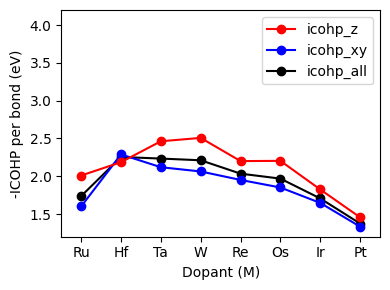

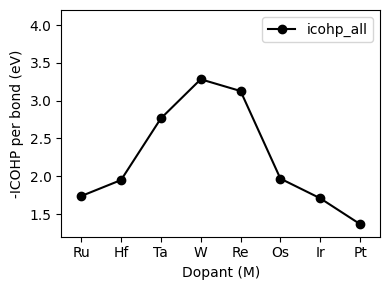

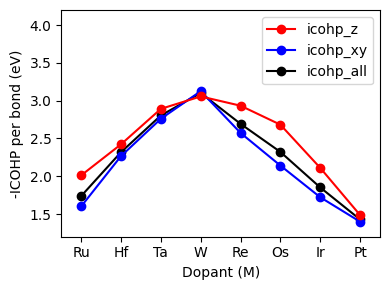

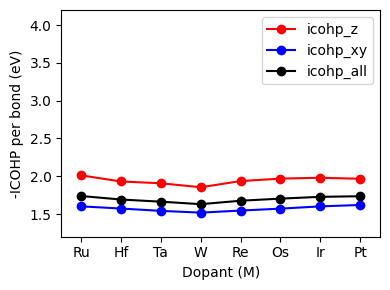

In [111]:
for oxides in ['MO2', 'MxOy', 'M-RuO2(M)', 'M-RuO2(Ru)']:
    plt.figure(figsize=figsize)

    cols = [col for col in data.columns if f'{oxides}_icohp_' in col]
    labels = ['icohp_z', 'icohp_xy', 'icohp_all']
    colors = ['red', 'blue', 'black']
    zorders = [3, 2, 1]

    if oxides == 'MxOy':
        labels = ['icohp_all']
        colors = ['black']
        zorders = [1]

    for i, col in enumerate(cols):
        if col in data.columns:
            plt.plot(
                data.index, 
                data[col], 
                marker='o', 
                label=labels[i % len(labels)], 
                color=colors[i % len(colors)], 
                zorder=zorders[i % len(zorders)]
            )

    plt.xlabel('Dopant (M)')
    plt.ylabel('-ICOHP per bond (eV)')
    plt.ylim(1.2, 4.2)

    plt.xlim(-0.5, 7.5)
    plt.legend(loc='best')
    plt.xticks(range(len(data.index)), data.index.tolist())
    
    plt.tight_layout()
    plt.savefig(f'{root}/figures/icohp_{oxides}.png', dpi=dpi, transparent=True)
    plt.show()
    plt.close()

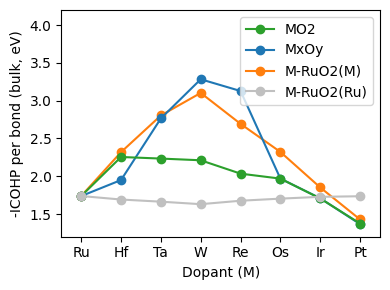

In [112]:
plt.figure(figsize=figsize)

cols = ['MO2_icohp_all', 'MxOy_icohp_all', 'M-RuO2(M)_icohp_all', 'M-RuO2(Ru)_icohp_all']
labels = ['MO2', 'MxOy', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [3, 2, 1, 4]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP per bond (bulk, eV)')
plt.ylim(1.2, 4.2)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_icohp_per_bond.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

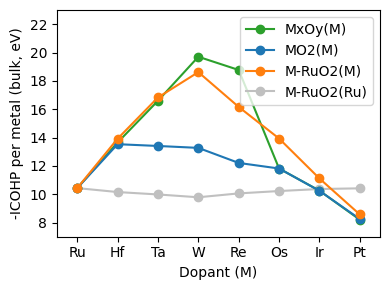

In [113]:
data['MO2_icohp'] = data['MO2_icohp_all']*6
data['M-RuO2(M)_icohp'] = data['M-RuO2(M)_icohp_all']*6
data['M-RuO2(Ru)_icohp'] = data['M-RuO2(Ru)_icohp_all']*6

plt.figure(figsize=figsize)

cols = ['MxOy_icohp', 'MO2_icohp', 'M-RuO2(M)_icohp', 'M-RuO2(Ru)_icohp']
labels = ['MxOy(M)', 'MO2(M)', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [2, 3, 4, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP per metal (bulk, eV)')
plt.ylim(7, 23)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_icohp_per_metal.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [114]:
for coverage in ['V', 'O']:
    if coverage == 'V':
        RuO2_path = os.path.join(root, '4_slab_M-RuO2', '1_cus_V_V', '0_Ru')
        dirs = ['1_cus_V_V', '2_brg_V_V']
    elif coverage == 'O':
        RuO2_path = os.path.join(root, '4_slab_M-RuO2', '3_cus_O_O', '0_Ru')
        dirs = ['3_cus_O_O', '4_brg_O_O']

    RuO2_atoms = read(os.path.join(RuO2_path, 'final_with_calculator.json'))
    RuO2_energy = RuO2_atoms.get_potential_energy()

    for dir in dirs:
        ads_site = dir.split('_')[1]

        for subdir in subdirs:
            element = subdir.split('_')[1]
            path = os.path.join(root, '4_slab_M-RuO2', dir, subdir)
            energy_file = os.path.join(path, 'final_with_calculator.json')
            if os.path.exists(energy_file):
                atoms = read(energy_file)
                energy = atoms.get_potential_energy()
                
                # doping_energy_MxOy = (energy - data['MxOy_energy'][element] + oxygen_potential * data['MxOy_os'][element] / 2) \
                #     - (RuO2_energy - data['MxOy_energy']['Ru'] + oxygen_potential * data['MxOy_os']['Ru'] / 2)
                # data.loc[element, f'{ads_site}_{coverage}_de_MxOy'] = doping_energy_MxOy

                doping_energy_MO2 = (energy - data['MO2_energy'][element]) - (RuO2_energy - data['MO2_energy']['Ru'])
                data.loc[element, f'{ads_site}_{coverage}_de_MO2'] = doping_energy_MO2

            chg_file = os.path.join(path, 'atoms_bader_charge.json')
            if element == 'Ru' and ads_site == 'brg':
                M_index = 13
            else:
                M_index = 15
            if os.path.exists(chg_file):
                atoms = read(chg_file)
                M_chg = atoms.get_initial_charges()[M_index]
                data.loc[element, f'{ads_site}_{coverage}_chg_M'] = M_chg
                
data


,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp,MxOy_icohp_all,M-RuO2(Ru)_icohp_z,M-RuO2(Ru)_icohp_xy,M-RuO2(Ru)_icohp_all,M-RuO2(M)_icohp_z,M-RuO2(M)_icohp_xy,M-RuO2(M)_icohp_all,MO2_icohp,M-RuO2(M)_icohp,M-RuO2(Ru)_icohp,cus_V_de_MO2,cus_V_chg_M,brg_V_de_MO2,brg_V_chg_M,cus_O_de_MO2,cus_O_chg_M,brg_O_de_MO2,brg_O_chg_M
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,10.43,1.74,2.01,1.60,1.74,2.01,1.60,1.74,10.43,10.43,10.43,0.00,1.68,0.00,1.76,0.00,1.83,0.00,1.80
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,13.65,1.95,1.93,1.57,1.69,2.42,2.27,2.32,13.53,13.91,10.15,0.40,2.38,0.30,2.26,7.00,2.35,0.55,8.33
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,16.59,2.77,1.91,1.54,1.66,2.89,2.76,2.80,13.40,16.83,9.98,-1.09,2.64,-1.79,2.67,-1.22,2.55,-1.73,8.56
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,19.70,3.28,1.85,1.52,1.63,3.06,3.13,3.10,13.27,18.62,9.78,-0.62,2.62,-2.03,2.61,-1.70,2.72,-2.11,10.63
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,18.77,3.13,1.94,1.55,1.68,2.93,2.57,2.69,12.21,16.16,10.06,-0.48,2.42,-1.64,2.47,-1.84,2.41,-1.99,2.56
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,11.81,1.97,1.97,1.57,1.70,2.68,2.14,2.32,11.81,13.93,10.22,0.19,1.93,-0.54,2.16,-1.03,2.19,-0.55,2.11
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,1.83,1.65,1.71,10.25,1.71,1.98,1.60,1.73,2.11,1.72,1.85,10.24,11.11,10.37,0.41,1.58,-0.11,1.70,0.00,1.89,0.08,1.76
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,1.46,1.33,1.37,8.20,1.37,1.97,1.62,1.74,1.49,1.40,1.43,8.25,8.57,10.41,-0.26,1.21,-0.55,1.50,0.57,1.68,-0.27,1.58


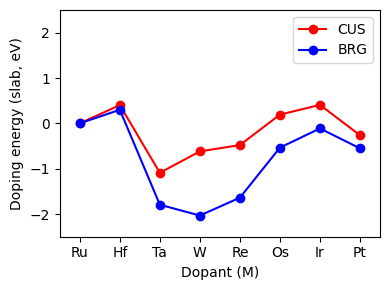

In [115]:
plt.figure(figsize=figsize)

cols = ['cus_V_de_MO2', 'brg_V_de_MO2']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('Doping energy (slab, eV)')
plt.ylim(-2.5, 2.5)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_doping_energy.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

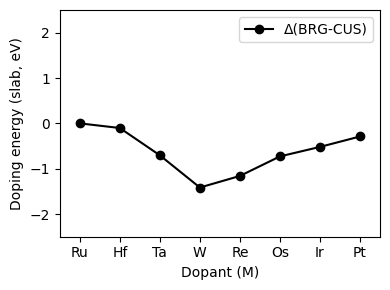

In [116]:
data['O_Δde'] = data['brg_O_de_MO2'] - data['cus_O_de_MO2']
data['V_Δde'] = data['brg_V_de_MO2'] - data['cus_V_de_MO2']

plt.figure(figsize=figsize)

plt.plot(
    data.index, 
    data['V_Δde'], 
    marker='o', 
    label='Δ(BRG-CUS)', 
    color='black', 
)

plt.xlabel('Dopant (M)')
plt.ylabel('Doping energy (slab, eV)')
plt.ylim(-2.5, 2.5)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_site_preference.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

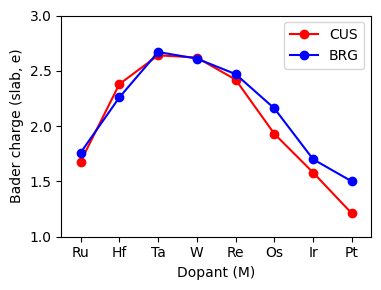

In [117]:
plt.figure(figsize=figsize)

cols = ['cus_V_chg_M', 'brg_V_chg_M']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (slab, e)')
plt.ylim(1.0, 3.0)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

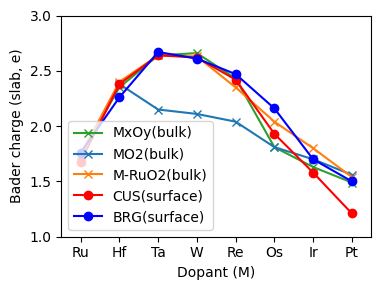

In [118]:
plt.figure(figsize=figsize)

cols = ['MxOy_chg', 'MO2_chg', 'M-RuO2_chg_M', 'cus_V_chg_M', 'brg_V_chg_M']
labels = ['MxOy(bulk)', 'MO2(bulk)', 'M-RuO2(bulk)', 'CUS(surface)', 'BRG(surface)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'red', 'blue']
zorders = [2, 1, 3, 4, 5]

for i, col in enumerate(cols):
    label=labels[i % len(labels)]
    if 'bulk' in label:
        marker = 'x'
    else:
        marker = 'o'
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker=marker, 
            label=label, 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (slab, e)')
plt.ylim(1.0, 3.0)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [123]:
def get_icohp_sum(icohp_file):
    """Return the numeric value from the last '-ICOHP sum:' line."""
    with open(icohp_file, 'r') as file:
        for line in reversed(file.readlines()):
            match = re.search(r"-ICOHP\s*sum\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", line)
            if match:
                return float(match.group(1))
    return None

for dir in ['1_cus_V_V', '2_brg_V_V', '3_cus_O_O', '4_brg_O_O']:
    ads_site = dir.split('_')[1]
    coverage = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        icohp_file = os.path.join(root, '4_slab_M-RuO2', 'cohp', dir, subdir, 'icohplist.txt')

        if os.path.exists(icohp_file):
            icohp_sum = get_icohp_sum(icohp_file)
            if icohp_sum is not None:
                data.loc[element, f'{ads_site}_{coverage}_icohp_M'] = icohp_sum

data[['cus_V_icohp_M', 'brg_V_icohp_M']]

,cus_V_icohp_M,brg_V_icohp_M
Ru,9.48,11.21
Hf,12.56,12.94
Ta,16.13,16.72
W,17.68,19.18
Re,NaN,NaN
Os,12.33,14.66
Ir,NaN,NaN
Pt,NaN,NaN


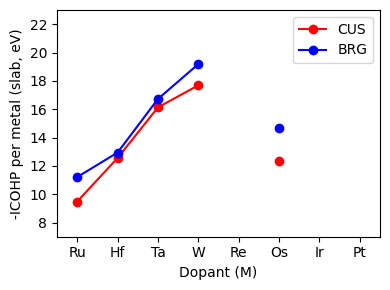

In [122]:
plt.figure(figsize=figsize)

cols = ['cus_V_icohp_M', 'brg_V_icohp_M']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP per metal (slab, eV)')
plt.ylim(7, 23)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_icohp_per_metal.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [121]:
data['V_Δicohp'] = data['brg_V_icohp_M'] - data['cus_V_icohp_M']
data['O_Δicohp'] = data['brg_O_icohp_M'] - data['cus_O_icohp_M']
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp,MxOy_icohp_all,M-RuO2(Ru)_icohp_z,M-RuO2(Ru)_icohp_xy,M-RuO2(Ru)_icohp_all,M-RuO2(M)_icohp_z,M-RuO2(M)_icohp_xy,M-RuO2(M)_icohp_all,MO2_icohp,M-RuO2(M)_icohp,M-RuO2(Ru)_icohp,cus_V_de_MO2,cus_V_chg_M,brg_V_de_MO2,brg_V_chg_M,cus_O_de_MO2,cus_O_chg_M,brg_O_de_MO2,brg_O_chg_M,O_Δde,V_Δde,cus_V_icohp_M,brg_V_icohp_M,cus_O_icohp_M,brg_O_icohp_M,V_Δicohp,O_Δicohp
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,10.43,1.74,2.01,1.60,1.74,2.01,1.60,1.74,10.43,10.43,10.43,0.00,1.68,0.00,1.76,0.00,1.83,0.00,1.80,0.00,0.00,9.48,11.21,11.12,11.12,1.73,-0.00
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,13.65,1.95,1.93,1.57,1.69,2.42,2.27,2.32,13.53,13.91,10.15,0.40,2.38,0.30,2.26,7.00,2.35,0.55,8.33,-6.45,-0.10,12.56,12.94,13.03,13.40,0.38,0.37
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,16.59,2.77,1.91,1.54,1.66,2.89,2.76,2.80,13.40,16.83,9.98,-1.09,2.64,-1.79,2.67,-1.22,2.55,-1.73,8.56,-0.51,-0.70,16.13,16.72,16.78,16.79,0.60,0.01
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,19.70,3.28,1.85,1.52,1.63,3.06,3.13,3.10,13.27,18.62,9.78,-0.62,2.62,-2.03,2.61,-1.70,2.72,-2.11,10.63,-0.41,-1.42,17.68,19.18,19.11,19.21,1.50,0.09
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,18.77,3.13,1.94,1.55,1.68,2.93,2.57,2.69,12.21,16.16,10.06,-0.48,2.42,-1.64,2.47,-1.84,2.41,-1.99,2.56,-0.15,-1.16,NaN,NaN,NaN,NaN,NaN,NaN
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,11.81,1.97,1.97,1.57,1.70,2.68,2.14,2.32,11.81,13.93,10.22,0.19,1.93,-0.54,2.16,-1.03,2.19,-0.55,2.11,0.48,-0.73,12.33,14.66,16.59,15.34,2.34,-1.25
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,1.83,1.65,1.71,10.25,1.71,1.98,1.60,1.73,2.11,1.72,1.85,10.24,11.11,10.37,0.41,1.58,-0.11,1.70,0.00,1.89,0.08,1.76,0.08,-0.52,NaN,NaN,NaN,NaN,NaN,NaN
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,1.46,1.33,1.37,8.20,1.37,1.97,1.62,1.74,1.49,1.40,1.43,8.25,8.57,10.41,-0.26,1.21,-0.55,1.50,0.57,1.68,-0.27,1.58,-0.84,-0.29,NaN,NaN,NaN,NaN,NaN,NaN
